# **Uncovering Factors Affecting Medical Insurance Charges**



**Introduction**

*This project aimed to identify the primary individual characteristics that influence the cost of medical insurance charges. Utilizing a publicly available dataset, we performed a descriptive analysis to uncover patterns and relationships between various personal attributes and the charges incurred.*

The data used in this project is taken from the Kaggle data set, which contains information about individuals and their corresponding medical insurance charges, this includes the following:

- age: Age of the primary beneficiary.
- sex: Gender of the beneficiary.
- bmi: Body Mass Index (a measure of body fat based on height and weight).
- children: Number of children/dependents covered by insurance.
- smoker: Whether the beneficiary smokes or not.
- region: The beneficiary's residential area in the US (northeast, southeast, southwest, northwest).
- charges: Individual medical costs billed by health insurance.</p>

<p>-------------------------------------------------------------------------------------------------------------------------------------------------------</p>

# **Data Cleaning & Preparation**

In [7]:
import pandas as pd

df = pd.read_csv('insurance.csv')

In [8]:
print(df.head()) # Preview of the dataframe and its contents
print(df.info()) # Check basic info and check for missing values

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


***

***

# **Analysis & Visualization**

<p>Firstly, I want to check the Overall Average Insurance Charges from our dataset</p>


In [9]:
avg_charges = df['charges'].mean()
print(f"Overall Average Insurance Charges: ${avg_charges:,.2f}")

Overall Average Insurance Charges: $13,270.42


<p>Now, I look to examine if being a smoker significantly impacts insurance charges. This is an important factor when determining premium prices. To do this, I calculated the average charges for smokers vs non-smokers in the dataset.</p>

In [10]:
# Code to calculate average charges for smokers vs. non-smokers
smoker_charges = df.groupby('smoker')['charges'].mean().reset_index()
print("\nAverage Charges by Smoker Status:")
print(smoker_charges)


Average Charges by Smoker Status:
  smoker       charges
0     no   8434.268298
1    yes  32050.231832


<p>Below is a Bar Chart which shows a comparison between the average premium charges, grouped by smoker status</p>

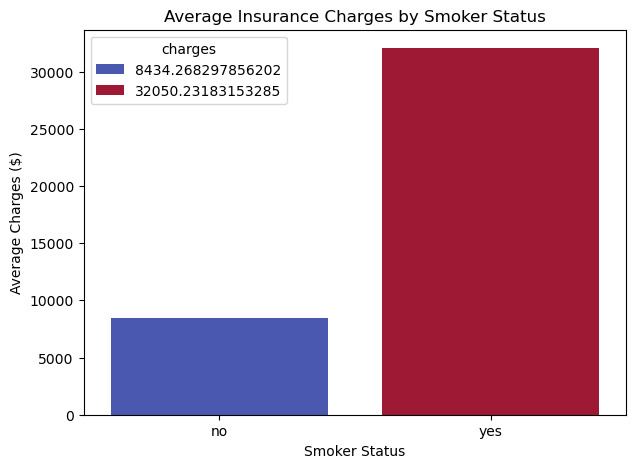

In [11]:
# Code to create Bar Chart
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.barplot(x='smoker', y='charges', data=smoker_charges, palette='coolwarm', hue='charges')
plt.title('Average Insurance Charges by Smoker Status')
plt.xlabel('Smoker Status')
plt.ylabel('Average Charges ($)')
plt.show()

<p>Now, we have a visual representation of the difference in premium charges for smokers vs non-smokers on average. We see that there is a clear difference between them of more than 300%</p>

***

<p>We can examine now if there is a difference in insurance charges acorss various regions of the United States.</p>


Average Charges by Region:
      region       charges
0  northeast  13406.384516
1  northwest  12417.575374
2  southeast  14735.411438
3  southwest  12346.937377


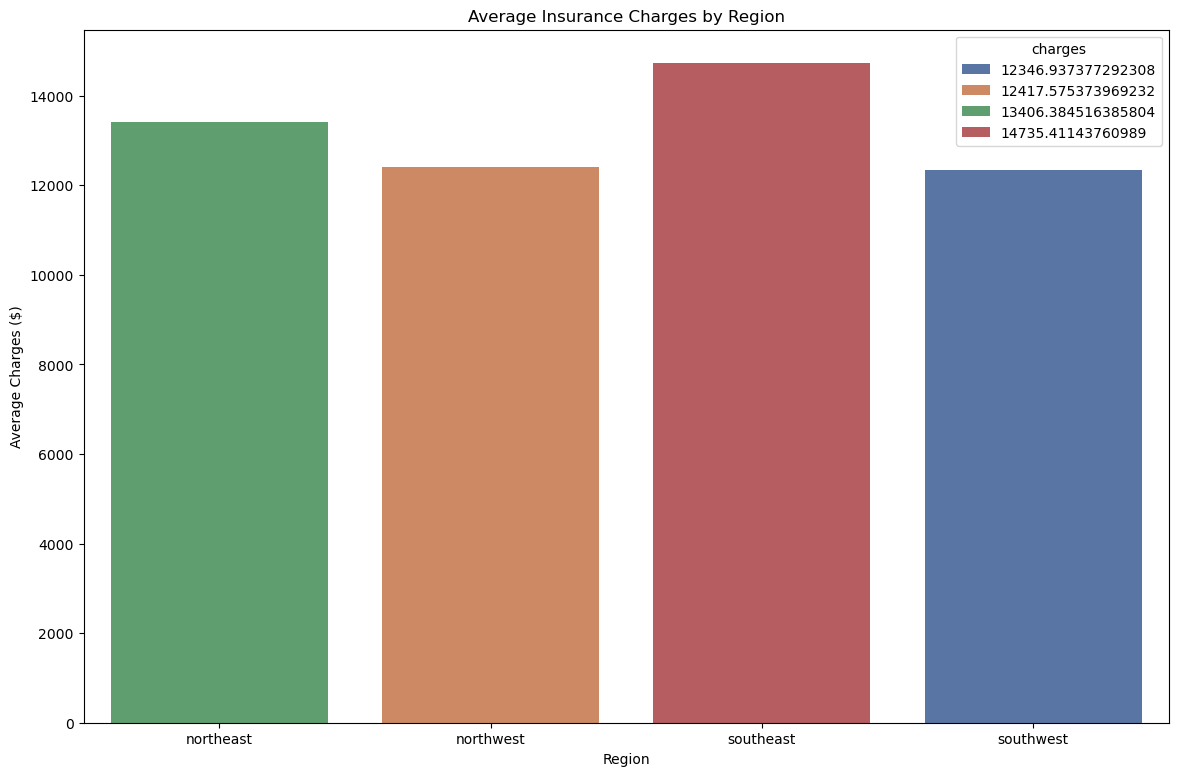

In [12]:
# Code to calculate average charges for each region
region_charges = df.groupby('region')['charges'].mean().reset_index()
print("\nAverage Charges by Region:")
print(region_charges)

# Code to create Bar Chart
plt.figure(figsize=(14, 9))
sns.barplot(x='region', y='charges', data=region_charges, palette='deep', hue='charges')
plt.title('Average Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Average Charges ($)')
plt.show()

***

<p>Next, the difference in charges between sexes is examined.</p>


Average Charges by Sex:
      sex       charges
0  female  12569.578844
1    male  13956.751178


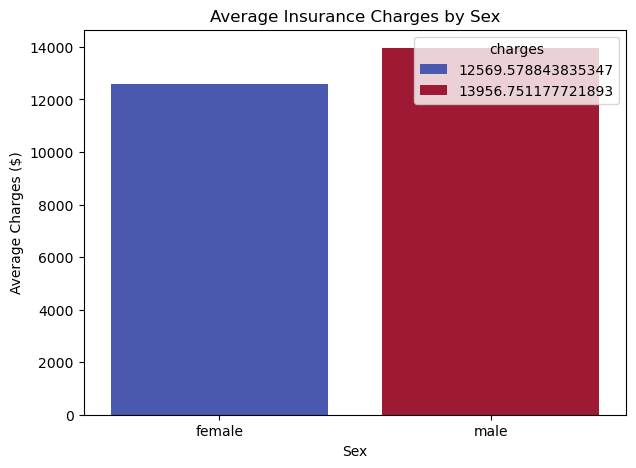

In [13]:
# Calculate average charges for each sex
sex_charges = df.groupby('sex')['charges'].mean().reset_index()
print("\nAverage Charges by Sex:")
print(sex_charges)

# Visualization: Bar Chart
plt.figure(figsize=(7, 5))
sns.barplot(x='sex', y='charges', data=sex_charges, palette='coolwarm', hue='charges')
plt.title('Average Insurance Charges by Sex')
plt.xlabel('Sex')
plt.ylabel('Average Charges ($)')
plt.show()

***

<p>The relationship between BMI and Charges is also examined. Does a higher BMI correspond with higher insurance charges?</p>

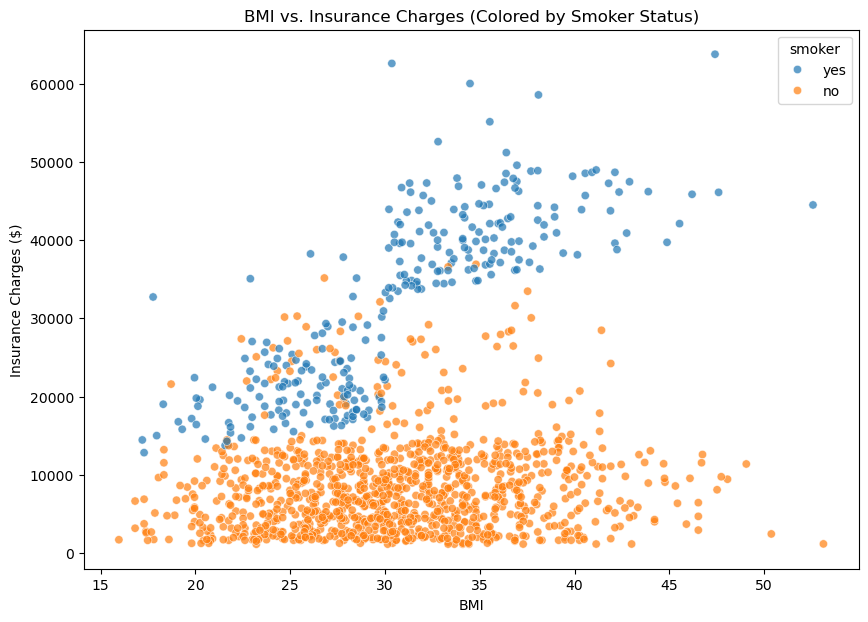

In [14]:
# Code to create a Scatter Plot to show relationship between the two numerical variables
plt.figure(figsize=(10, 7))
sns.scatterplot(x='bmi', y='charges', data=df, hue='smoker', palette='tab10', alpha=0.7)
plt.title('BMI vs. Insurance Charges (Colored by Smoker Status)')
plt.xlabel('BMI')
plt.ylabel('Insurance Charges ($)')
plt.show()

<p>We see that higher BMI often correlates with higher premium charges, especially for smokers.</p>

***

<p>Finally, we examine the relationship between Age of individuals and premium prices, I also made the decision to colour the plots, helping to uncover insights about how age affects charges differently for smokers and non-smokers.</p>

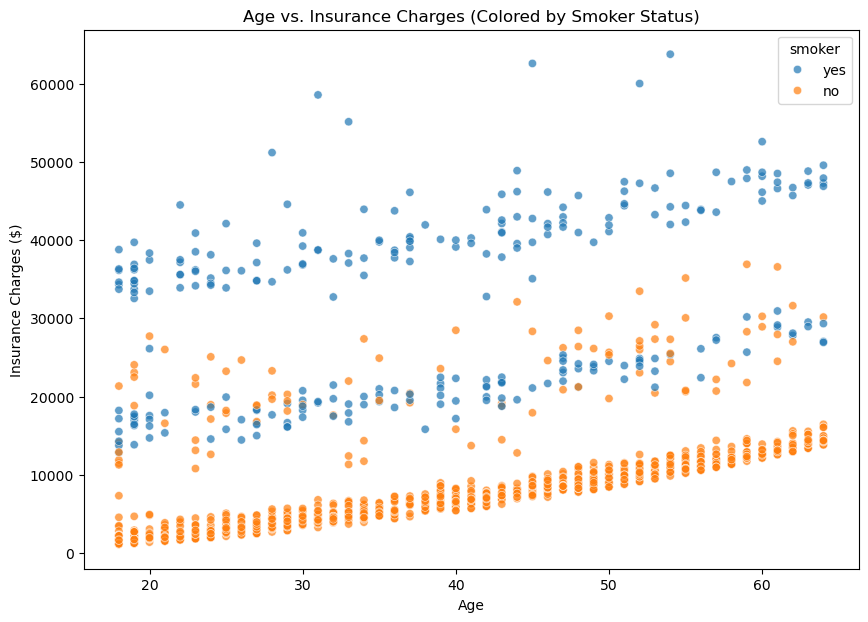

In [15]:
# Code to create Scatter Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x='age', y='charges', data=df, hue='smoker', palette='tab10', alpha=0.7)
plt.title('Age vs. Insurance Charges (Colored by Smoker Status)')
plt.xlabel('Age')
plt.ylabel('Insurance Charges ($)')
plt.show()

<p>Here, we can observe a general trend that as age increases, so do charges, especially for smokers.</p>

***

***

# **Key Findings**

Our analysis revealed several compelling insights into the factors that drive medical insurance costs:

#### Overall Charges: 
The average medical insurance charge across the dataset was found to be approximately $13,270.42. However, this average masks significant variations based on individual characteristics.

#### Profound Impact of Smoker Status: 
By far, the most significant factor influencing insurance charges is smoker status. Smokers faced drastically higher average charges, approximately \$32,050.23. 
In stark contrast, non-smokers had an average charge of \$8,434.27. This represents a difference of over $23,000, highlighting smoking as a critical risk factor for insurers.

#### Age and BMI Show Positive Correlation:
- **Age:** Our scatter plot clearly showed a general trend: as an individual's age increases, their insurance charges tend to rise. This relationship appears to be more pronounced, and often higher overall, for smokers.
- **BMI** (Body Mass Index): Similarly, individuals with a higher BMI generally incur greater insurance charges. The visualization highlighted that this trend is also significantly steeper for smokers, indicating a compounded effect of high BMI and smoking on costs.

#### Region and Sex with Lesser, but Present, Influence:
- **Region:** While less impactful than smoking, age, or BMI, there were noticeable differences in average charges across regions. For instance, the Southeast region often shows slightly higher average charges, potentially due to factors like local healthcare costs or regional health trends.
- **Sex:** The difference in average charges between male and female beneficiaries was minimal compared to other factors, suggesting that sex alone is not a dominant predictor of insurance costs in this datase

***

# **Discussion and Implications**

The findings from this analysis strongly suggest that lifestyle choices (like smoking) and health indicators like age and BMI are paramount in determining medical insurance premiums. The dramatic difference in charges between smokers and non-smokers underscores the high financial risk associated with smoking for insurance providers.

For individuals, these insights highlight the financial benefits of maintaining a healthy lifestyle, such as not smoking and managing BMI, which could lead to lower insurance costs. For insurance companies, these factors are crucial in risk assessment and premium calculation.

***

# **Limitations and Future Work**

This project provides some basic foundational understanding of key influencing factors. However, it's important to acknowledge its limitations:

- The dataset is a simplified representation and does not include other potentially crucial factors like specific medical history, pre-existing conditions, or detailed lifestyle choices.
- This analysis is correlational, meaning it shows associations, not direct causation.
The dataset is hypothetical/simulated and may not perfectly reflect the nuances of real-world insurance pricing.

For future work, one could:

- Develop a predictive machine learning model to estimate individual charges based on these and additional features.
- Investigate the interaction effects between more variables (e.g., how age and BMI combine to affect charges differently for smokers).
- Explore more granular demographic or socioeconomic factors if such data were available.

***